# Module 3 – Intent Classifier
### RAG-Based Mental Health Support Chatbot | NLP Final Task 2026

**Architecture:**
```
module3/
├── prompts.yaml          ← all prompts, few-shot examples, direct responses
├── schemas.py            ← Pydantic models (IntentRequest, IntentResponse ...)
├── intent_classifier.py  ← core logic, loads from prompts.yaml
├── main.py               ← FastAPI app, routes to RAG if needed
├── requirements.txt
└── .env
```

## 1. Install Dependencies

In [ ]:
!pip install -r requirements.txt scikit-learn matplotlib seaborn

## 2. Inspect prompts.yaml
All prompts, few-shot examples, and direct responses live here — no strings in code.

In [1]:
import yaml

with open("prompts.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

cfg = config["intent_classifier"]

print("=== System Prompt ===")
print(cfg["system_prompt"])

print(f"\n=== Few-Shot Examples ===")
examples = cfg["few_shot_examples"]
print(f"Total messages: {len(examples)} ({len(examples)//2} pairs)")

# Count per intent
from collections import Counter
labels = [e["content"] for e in examples if e["role"] == "assistant"]
for intent, count in Counter(labels).items():
    print(f"  {intent}: {count} examples")

print("\n=== Direct Responses ===")
for intent, response in cfg["direct_responses"].items():
    print(f"  [{intent}]\n    {response.strip()[:80]}...\n")

=== System Prompt ===
You are an intent classification engine for a mental health support chatbot.
Your ONLY job is to classify the user message into exactly ONE of these intents:
  greeting | goodbye | gratitude | asking_mental_health_question | out_of_scope

RULES:
1. Reply with the intent label ONLY. No explanation, no punctuation, nothing else.
2. If the message contains BOTH gratitude/greeting AND a mental health question,
   classify it as: asking_mental_health_question
3. Mental health topics include: anxiety, depression, stress, panic attacks,
   loneliness, grief, trauma, therapy, coping, self-harm, suicide, burnout,
   emotional pain, sleep issues caused by worry, and similar.
4. Messages in any language follow the same rules.


=== Few-Shot Examples ===
Total messages: 22 (11 pairs)
  greeting: 2 examples
  goodbye: 2 examples
  gratitude: 2 examples
  asking_mental_health_question: 3 examples
  out_of_scope: 2 examples

=== Direct Responses ===
  [greeting]
    Hello! I'm h

## 3. Inspect Pydantic Schemas

In [3]:
import json
from schemas import IntentRequest, IntentResponse, Intent

print("=== IntentRequest schema ===")
print(json.dumps(IntentRequest.model_json_schema(), indent=2))

print("\n=== IntentResponse schema ===")
print(json.dumps(IntentResponse.model_json_schema(), indent=2))

print("\n=== Valid intents ===")
for i in Intent:
    print(f"  {i.value}")

=== IntentRequest schema ===
{
  "properties": {
    "message": {
      "description": "The raw user message to classify.",
      "examples": [
        "I've been feeling really anxious lately."
      ],
      "maxLength": 2000,
      "minLength": 1,
      "title": "Message",
      "type": "string"
    },
    "language_code": {
      "anyOf": [
        {
          "type": "string"
        },
        {
          "type": "null"
        }
      ],
      "default": null,
      "description": "ISO 639-1 language code from Module 1 (e.g. 'en', 'ar').",
      "examples": [
        "en"
      ],
      "title": "Language Code"
    },
    "emotion": {
      "anyOf": [
        {
          "type": "string"
        },
        {
          "type": "null"
        }
      ],
      "default": null,
      "description": "Emotion label from Module 2 (e.g. 'sadness', 'fear').",
      "examples": [
        "sadness"
      ],
      "title": "Emotion"
    }
  },
  "required": [
    "message"
  ],
  "title": "

## 4. Test the Classifier (no API server needed)

In [4]:
import time
from intent_classifier import classify_intent, get_direct_response

smoke_tests = [
    ("Hi!",                                           Intent.GREETING),
    ("Goodbye, take care!",                          Intent.GOODBYE),
    ("Thank you so much!",                           Intent.GRATITUDE),
    ("I feel really anxious lately.",                Intent.ASKING_MENTAL_HEALTH),
    ("What's the capital of Japan?",                 Intent.OUT_OF_SCOPE),
    # Edge: mixed gratitude + mental health
    ("Thanks! Also, how do I manage panic attacks?", Intent.ASKING_MENTAL_HEALTH),
    # Arabic
    ("مرحبا كيف حالك",                               Intent.GREETING),
    ("أشعر بالاكتئاب كثيراً",                        Intent.ASKING_MENTAL_HEALTH),
]

print(f"{'Message':<52} {'Expected':<35} {'Got':<35} ✓")
print("-" * 130)

passed = 0
for msg, expected in smoke_tests:
    result = classify_intent(msg)
    ok = result == expected
    if ok: passed += 1
    print(f"{msg:<52} {expected.value:<35} {result.value:<35} {'✅' if ok else '❌'}")
    time.sleep(0.4)

print(f"\nResult: {passed}/{len(smoke_tests)} passed")

Message                                              Expected                            Got                                 ✓
----------------------------------------------------------------------------------------------------------------------------------
Hi!                                                  greeting                            greeting                            ✅
Goodbye, take care!                                  goodbye                             goodbye                             ✅
Thank you so much!                                   gratitude                           gratitude                           ✅
I feel really anxious lately.                        asking_mental_health_question       asking_mental_health_question       ✅
What's the capital of Japan?                         out_of_scope                        out_of_scope                        ✅
Thanks! Also, how do I manage panic attacks?         asking_mental_health_question       asking_mental_heal

## 5. Simulate the Full IntentResponse (as FastAPI would return it)

In [ ]:
from schemas import IntentResponse, RAGResponse, ActionType
from intent_classifier import classify_intent, get_direct_response

def simulate_response(message: str, language_code: str = "en", emotion: str = None) -> IntentResponse:
    """
    Mimics what main.py does — without needing the FastAPI server running.
    For mental health questions, returns a placeholder RAG response.
    """
    intent = classify_intent(message)

    if intent == Intent.ASKING_MENTAL_HEALTH:
        # In production → calls Module 4 RAG endpoint
        # Here we return a placeholder
        rag = RAGResponse(
            answer="[This is where Module 4 RAG answer would appear]",
            sources=["counseling_dataset_chunk_XX"],
            confidence=None
        )
        return IntentResponse(
            intent=intent,
            action=ActionType.FORWARD_TO_RAG,
            rag_response=rag,
            language_code=language_code,
            emotion=emotion
        )

    return IntentResponse(
        intent=intent,
        action=ActionType.DIRECT_RESPONSE,
        direct_response=get_direct_response(intent),
        language_code=language_code,
        emotion=emotion
    )


# Demo
demo = [
    ("Hi!",                                           "en", None),
    ("I've been having a lot of panic attacks.",     "en", "fear"),
    ("شكرا جزيلا",                                   "ar", "joy"),
    ("What is 2 + 2?",                               "en", None),
    ("Bye!",                                         "en", None),
]

for msg, lang, emotion in demo:
    resp = simulate_response(msg, lang, emotion)
    print(f"\nInput   : {msg}")
    print(f"Intent  : {resp.intent.value}")
    print(f"Action  : {resp.action.value}")
    if resp.direct_response:
        print(f"Response: {resp.direct_response}")
    if resp.rag_response:
        print(f"RAG     : {resp.rag_response.answer}")
    time.sleep(0.4)

ImportError: cannot import name 'RAGResponse' from 'schemas' (d:\NLP\RAG-Based-Mental-Health-Support\Intent-classifier\schemas.py)

## 6. Evaluation

In [6]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

eval_data = [
    # greeting
    {"text": "Hi!",                                             "label": "greeting"},
    {"text": "Hello!",                                          "label": "greeting"},
    {"text": "Good morning!",                                   "label": "greeting"},
    {"text": "Hey, how are you?",                               "label": "greeting"},
    {"text": "مرحبا",                                           "label": "greeting"},
    {"text": "Bonjour",                                         "label": "greeting"},
    {"text": "Hey there!",                                      "label": "greeting"},
    {"text": "Hi, I'm back!",                                   "label": "greeting"},
    # goodbye
    {"text": "Goodbye!",                                        "label": "goodbye"},
    {"text": "See you later!",                                  "label": "goodbye"},
    {"text": "Bye bye!",                                        "label": "goodbye"},
    {"text": "مع السلامة",                                      "label": "goodbye"},
    {"text": "I'm done. Goodbye.",                             "label": "goodbye"},
    {"text": "Take care, I'm leaving.",                        "label": "goodbye"},
    {"text": "Catch you later!",                               "label": "goodbye"},
    {"text": "Have a great day, I'm off!",                     "label": "goodbye"},
    # gratitude
    {"text": "Thank you so much!",                             "label": "gratitude"},
    {"text": "I really appreciate your help.",                 "label": "gratitude"},
    {"text": "That was very helpful, thank you.",              "label": "gratitude"},
    {"text": "شكرا جزيلا",                                     "label": "gratitude"},
    {"text": "You really helped me today.",                    "label": "gratitude"},
    {"text": "I'm grateful for your support.",                 "label": "gratitude"},
    {"text": "Appreciate it!",                                 "label": "gratitude"},
    {"text": "Merci beaucoup!",                                "label": "gratitude"},
    # asking_mental_health_question
    {"text": "I've been really anxious lately.",               "label": "asking_mental_health_question"},
    {"text": "How do I cope with depression?",                 "label": "asking_mental_health_question"},
    {"text": "I feel hopeless and don't know what to do.",    "label": "asking_mental_health_question"},
    {"text": "What are signs of a panic attack?",             "label": "asking_mental_health_question"},
    {"text": "I can't sleep because of constant worrying.",   "label": "asking_mental_health_question"},
    {"text": "أشعر بالاكتئاب وأحتاج للمساعدة",                "label": "asking_mental_health_question"},
    {"text": "Thanks! Also, what helps with burnout?",         "label": "asking_mental_health_question"},
    {"text": "I've been feeling really stressed about work.", "label": "asking_mental_health_question"},
    # out_of_scope
    {"text": "What is the capital of Japan?",                  "label": "out_of_scope"},
    {"text": "Can you write a poem?",                          "label": "out_of_scope"},
    {"text": "How do I make pasta?",                           "label": "out_of_scope"},
    {"text": "What's the weather like today?",                 "label": "out_of_scope"},
    {"text": "Who won the Champions League?",                  "label": "out_of_scope"},
    {"text": "Tell me a joke.",                               "label": "out_of_scope"},
    {"text": "What is 15 times 12?",                          "label": "out_of_scope"},
    {"text": "Book me a flight to Paris.",                    "label": "out_of_scope"},
]

df = pd.DataFrame(eval_data)
print(f"Dataset: {len(df)} examples")
print(df["label"].value_counts())

Dataset: 40 examples
label
greeting                         8
goodbye                          8
gratitude                        8
asking_mental_health_question    8
out_of_scope                     8
Name: count, dtype: int64


In [7]:
print("Running evaluation...")
preds = []
for i, row in df.iterrows():
    preds.append(classify_intent(row["text"]).value)
    time.sleep(0.4)
    if (i + 1) % 8 == 0:
        print(f"  ✅ {i+1}/{len(df)} done")

df["predicted"] = preds
print("\nDone!")

Running evaluation...
  ✅ 8/40 done
  ✅ 16/40 done
  ✅ 24/40 done
  ✅ 32/40 done
  ✅ 40/40 done

Done!


Accuracy: 100.00%

                               precision    recall  f1-score   support

                     greeting       1.00      1.00      1.00         8
                      goodbye       1.00      1.00      1.00         8
                    gratitude       1.00      1.00      1.00         8
asking_mental_health_question       1.00      1.00      1.00         8
                 out_of_scope       1.00      1.00      1.00         8

                     accuracy                           1.00        40
                    macro avg       1.00      1.00      1.00        40
                 weighted avg       1.00      1.00      1.00        40



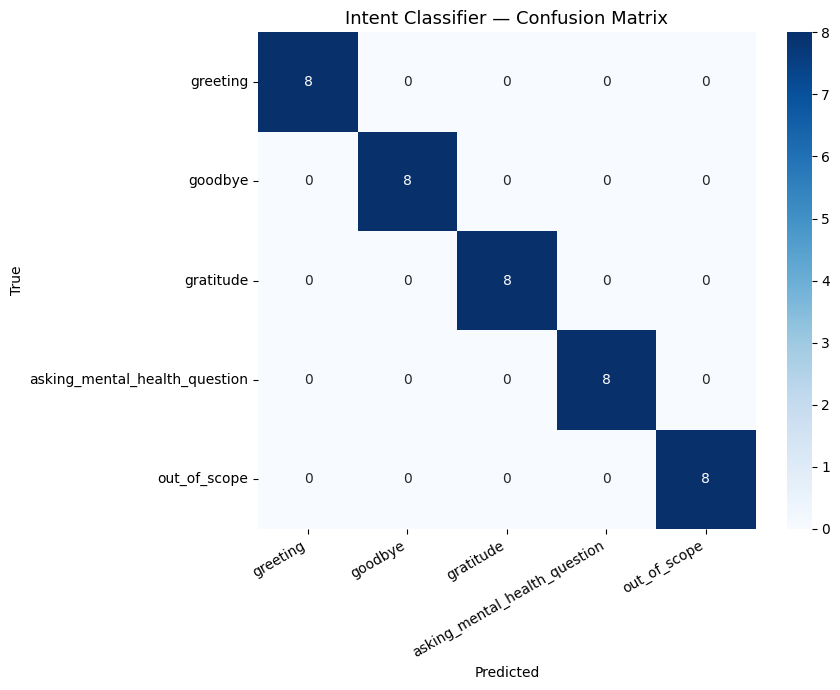

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

VALID_INTENTS = [i.value for i in Intent]
y_true, y_pred = df["label"], df["predicted"]

print(f"Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
print(classification_report(y_true, y_pred, target_names=VALID_INTENTS))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=VALID_INTENTS)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=VALID_INTENTS, yticklabels=VALID_INTENTS, ax=ax)
ax.set_title("Intent Classifier — Confusion Matrix", fontsize=13)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.xticks(rotation=30, ha="right"); plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 7. Run the FastAPI Server

From the terminal inside the `module3/` folder:

```bash
# 1. Copy and fill your .env
cp .env.example .env

# 2. Install dependencies
pip install -r requirements.txt

# 3. Start the server
python main.py

# 4. Open interactive docs
#    http://localhost:8000/docs
```

### Example request
```bash
curl -X POST http://localhost:8000/classify \
  -H "Content-Type: application/json" \
  -d '{"message": "I feel really anxious about everything", "language_code": "en", "emotion": "fear"}'
```

### Example response
```json
{
  "intent": "asking_mental_health_question",
  "action": "forward_to_rag",
  "direct_response": null,
  "rag_response": {
    "answer": "Anxiety can be managed through...",
    "sources": ["counseling_chunk_42"],
    "confidence": 0.91
  },
  "language_code": "en",
  "emotion": "fear"
}
```